<a href="https://colab.research.google.com/github/PallavKhanal/MachineLearningProjects/blob/main/Loan_Approval_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Trees — Complete Guide

🔗 Building On What You Already Know
You've now learned two models:
Linear Regression — draws a straight line through data. The decision boundary is always linear. It assumes the relationship between features and output is a weighted sum.
Logistic Regression — same idea but wraps that line in a sigmoid to output probabilities. Still fundamentally linear — the boundary is still a straight line (or hyperplane).
Here's the problem with both of them. What if the relationship in your data isn't linear?
Imagine predicting loan approval. Maybe the rule is:

If income > $50k AND age > 25 → approve
If income > $50k AND age <= 25 AND employed > 2 years → approve
Otherwise → reject

No straight line can capture that. It's a series of if-then rules — nested conditions that split the data into groups.
That's exactly what a Decision Tree does.

🌳 What Is a Decision Tree?
A decision tree is literally a flowchart of yes/no questions.
                    Is income > $50k?
                   /                 \
                 YES                  NO
                  |                   |
         Is age > 25?            → REJECT
        /            \
      YES              NO
       |                |
   → APPROVE     Is employed > 2yr?
                /                  \
              YES                   NO
               |                    |
           → APPROVE            → REJECT
Each internal node asks a question about one feature.
Each branch is the answer (yes/no, or above/below a threshold).
Each leaf node is a final decision — approve or reject.
The model learns WHICH questions to ask and in WHAT ORDER by looking at the training data. Your job as the data scientist is to control how deep and complex the tree gets.

✂️ How Does It Decide What to Split On?
At every node, the tree considers every feature and every possible threshold for that feature. It picks the split that makes the resulting groups as pure as possible.
Pure means: one group is mostly class 1, the other is mostly class 0. If you split perfectly, one side has only approvals and the other has only rejections.
To measure impurity, we use either Gini Impurity or Entropy.

📐 Core Theory: Gini Impurity and Entropy
Both measure the same thing — how mixed up a group is. They just measure it slightly differently. You don't need to derive them, but you need to understand what they're saying.

Gini Impurity
Gini = 1 - Σ pᵢ²
Where pᵢ is the proportion of class i in the node.
Think of it this way. If you randomly picked two passengers from a node and compared their labels, what's the probability they're different?

Pure node (all same class): Gini = 0. If everyone is "approved", you'll never pick two different labels.
Perfectly mixed node (50/50 split): Gini = 0.5. Half the time you'll pick two different labels.

Gini ranges from 0 (pure) to 0.5 (maximally impure) for binary classification.
Example: a node with 80% approved, 20% rejected:
Gini = 1 - (0.8² + 0.2²) = 1 - (0.64 + 0.04) = 1 - 0.68 = 0.32
A node with 50/50:
Gini = 1 - (0.5² + 0.5²) = 1 - (0.25 + 0.25) = 0.50
The tree picks whichever split produces children nodes with the lowest weighted average Gini.

Entropy
Entropy = -Σ pᵢ · log₂(pᵢ)
Entropy comes from information theory. It measures uncertainty or surprise.

Pure node: Entropy = 0. You already know the answer — no surprise.
Perfectly mixed node: Entropy = 1. Maximum uncertainty.

Example: 80/20 split:
Entropy = -(0.8 · log₂(0.8) + 0.2 · log₂(0.2))
        = -(0.8 · (-0.322) + 0.2 · (-2.322))
        = -(-0.258 - 0.464)
        = 0.722
50/50 split:
Entropy = -(0.5 · log₂(0.5) + 0.5 · log₂(0.5))
        = -(0.5 · (-1) + 0.5 · (-1))
        = 1.0
Gini vs Entropy in practice: they almost always produce identical trees. Gini is slightly faster to compute (no logarithm). Entropy is more theoretically grounded. sklearn defaults to Gini — just leave it.

Information Gain (The Deep Math)
When the tree makes a split, it computes Information Gain — how much did this split reduce entropy?
IG = Entropy(parent) - [weighted average Entropy of children]
Weighted average means: weight each child's entropy by what fraction of the data went to it.
IG = H(parent) - (n_left/n · H(left) + n_right/n · H(right))
The tree picks the split that maximizes information gain — the split that reduces uncertainty the most.
Example:

Parent node: 50/50 split, Entropy = 1.0
After split: left child is 90/10 (Entropy = 0.47), right child is 10/90 (Entropy = 0.47)
50% of data went left, 50% went right

IG = 1.0 - (0.5 · 0.47 + 0.5 · 0.47) = 1.0 - 0.47 = 0.53
Large information gain — this was a great split. The tree found a question that cleanly separated the classes.

🌊 Why Deep Trees Overfit
This is one of the most important concepts in all of machine learning — not just decision trees.
Imagine you let the tree grow until every leaf contains exactly one training example. The tree achieves 100% accuracy on training data. It has memorized every single data point.
But then you show it a new loan application it's never seen. It has no idea what to do — it learned patterns so specific to the training data that they don't generalize.
Here's a concrete example:
Training data has this person: age=34, income=$52,400, employed=3.2 years → approved
A very deep tree might learn the rule: "if age is exactly 34 AND income is between $52,300 and $52,500 → approve." That rule is useless for anyone else.
A shallow tree learns: "if income > $50k AND employed > 2 years → approve." That generalizes.
Bias-Variance Tradeoff:

Too shallow → high bias (underfitting). The tree is too simple to capture real patterns. It makes systematic mistakes.
Too deep → high variance (overfitting). The tree is so complex it captures noise. It works perfectly on training data and fails on new data.

The goal is the sweet spot in the middle.

🎛️ How to Control Overfitting
These are the knobs you turn:
max_depth — maximum number of levels the tree can grow.
The most important parameter. Start with 3-5. A tree of depth 3 can express 2³=8 different rules — usually enough to capture real patterns without memorizing noise.
min_samples_split — minimum number of samples a node must have before it's allowed to split.
If a node has only 3 people in it, splitting further is almost certainly overfitting. Setting this to 20 means "don't split unless you have at least 20 examples to learn from."
min_samples_leaf — minimum number of samples that must end up in each leaf.
Even stricter — the split is only allowed if BOTH resulting children have at least this many samples. Prevents tiny, highly specific leaf nodes.
max_features — how many features to consider at each split.
Instead of considering all features, consider a random subset. Adds randomness that helps generalization. This becomes critical in Random Forests (next topic).
ccp_alpha — cost complexity pruning.
After the tree is grown, prune back branches that don't add enough predictive value. A more principled approach than just limiting depth.

🏆 Feature Importance
After training, a decision tree can tell you which features it found most useful.
Feature importance is computed as: how much did each feature reduce impurity across all splits where it was used, weighted by how many samples passed through those splits?
A feature used near the root (early splits) gets higher importance because early splits affect more data. A feature used only in deep, tiny branches gets low importance.
This gives you a ranking:
income_annual      → 0.42
credit_score       → 0.28
employment_years   → 0.15
loan_amount        → 0.09
age                → 0.06
These sum to 1.0. The model spent 42% of its "splitting budget" on income — it found income to be the most informative feature for separating approvals from rejections.
Important caveat: feature importance in decision trees is biased toward features with many possible thresholds (continuous features) and features with high cardinality. Don't treat it as ground truth — treat it as a useful signal.

In [ ]:
# Goal: predict whether a loan application will be approved (1)
# or rejected (0) based on applicant information.
#
# We'll use a synthetic but realistic loan dataset from OpenML.
# The pipeline follows the same structure you learned in
# Titanic and Ames Housing — load, explore, clean, engineer,
# encode, split, scale, train, evaluate.
#
# New things introduced in this project:
#   - Decision tree training and depth tuning
#   - Visualizing the tree
#   - Feature importance plots
#   - Comparing a shallow tree vs deep tree to see overfitting

In [ ]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# loading the data

# We're using the "credit-g" dataset from OpenML — also known as
# the German Credit dataset. It contains 1,000 loan applications
# with 20 features about each applicant.
#
# Target: 'class' — 'good' (loan approved) or 'bad' (loan rejected)
# This is a real-world dataset used in credit risk modeling.

credit = fetch_openml(name='credit-g', as_frame=True, version=1)

df = credit.data.copy()
df['target'] = credit.target.copy()
# The target comes back as 'good'/'bad' strings.
# We'll convert to 1/0 later.

print(f"Dataset shape: {df.shape}")
# (1000, 21) — 1000 loan applications, 20 features + target

print("\nFirst 5 rows:")
print(df.head())


print("\nColumn names and types:")
print(df.dtypes)
# You'll see a mix of numeric and categorical (object) columns.
# This is typical of financial datasets.

print("\nTarget distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))
# 'good': 700 (70%), 'bad': 300 (30%)
# Imbalanced — 70/30 split. Not extreme but worth handling.



Dataset shape: (1000, 21)

First 5 rows:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single          none  ...   
1                      

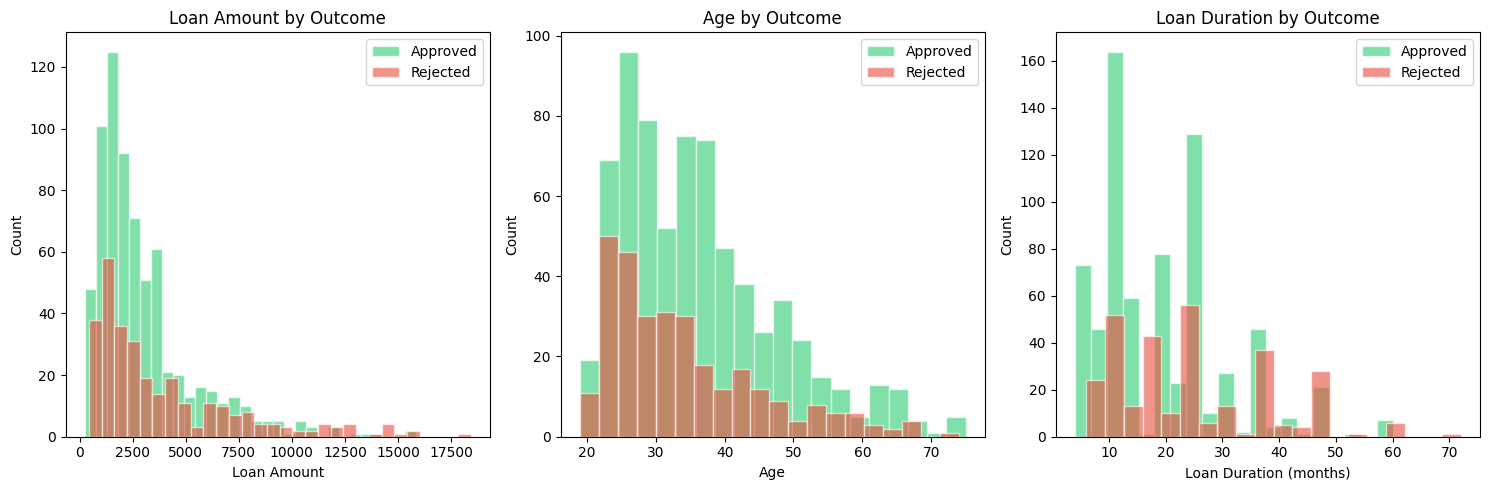

In [ ]:
#exploring the data

# Before touching anything, understand what you're working with.
# Which features look like they separate approvals from rejections?

plt.figure(figsize=(15, 5))

# ── Credit amount by outcome ──────────────────────────────────
plt.subplot(1, 3, 1)
df['credit_amount'] = pd.to_numeric(df['credit_amount'], errors='coerce')
# Convert to numeric first — fetch_openml sometimes returns as string

good_mask = df['target'] == 'good'
bad_mask = df['target'] == 'bad'

plt.hist(df.loc[good_mask, 'credit_amount'], bins=30, alpha=0.6,
         color='#2ecc71', label='Approved', edgecolor='white')
plt.hist(df.loc[bad_mask, 'credit_amount'], bins=30, alpha=0.6,
         color='#e74c3c', label='Rejected', edgecolor='white')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.title('Loan Amount by Outcome')
plt.legend()


# ── Age by outcome ────────────────────────────────────────────
plt.subplot(1, 3, 2)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

plt.hist(df.loc[good_mask, 'age'], bins=20, alpha=0.6,
         color='#2ecc71', label='Approved', edgecolor='white')
plt.hist(df.loc[bad_mask, 'age'], bins=20, alpha=0.6,
         color='#e74c3c', label='Rejected', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age by Outcome')
plt.legend()

# Older applicants slightly more likely to be approved.


# ── Duration by outcome ───────────────────────────────────────
plt.subplot(1, 3, 3)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

plt.hist(df.loc[good_mask, 'duration'], bins=20, alpha=0.6,
         color='#2ecc71', label='Approved', edgecolor='white')
plt.hist(df.loc[bad_mask, 'duration'], bins=20, alpha=0.6,
         color='#e74c3c', label='Rejected', edgecolor='white')
plt.xlabel('Loan Duration (months)')
plt.ylabel('Count')
plt.title('Loan Duration by Outcome')
plt.legend()
# Longer loan terms more often rejected — higher risk for the bank.

plt.tight_layout()
plt.show()


In [ ]:
#handling missing values and fixing the datatypes

# This dataset from OpenML is relatively clean but fetch_openml
# sometimes encodes numeric columns as strings or categories.
# We need to ensure everything is the right type before modeling.

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))
# This dataset has very few actual NaNs — most values are present.
# But we still need to fix dtypes.


# ── Convert all numeric columns to proper float ───────────────
numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                'residence_since', 'age', 'existing_credits', 'num_dependents']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # errors='coerce': any value that can't become a number → NaN
        df[col] = df[col].fillna(df[col].median())
        # Fill any resulting NaNs with median — safe default for numeric columns

# ── Convert target to binary integer ─────────────────────────
#
# Decision trees in sklearn need numeric targets for classification.
# 'good' → 1 (approved), 'bad' → 0 (rejected)
# We define 'good' as 1 because it's the outcome we're most interested in predicting.

df['target_binary'] = (df['target'] == 'good').astype(int)
# (df['target'] == 'good') returns True/False
# .astype(int) converts True → 1, False → 0


Missing values:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
target                    0
dtype: int64


In [ ]:
#feature engineering

# Same philosophy as Titanic and Ames — domain knowledge encoded
# as new features that the model can't easily derive on its own.
# Think like a loan officer: what combinations of information
# tell you if someone is a good credit risk?

df['loan_to_age_ratio'] = df['credit_amount'] / (df['age'] + 1)
# How large is this loan relative to the applicant's age?
# A 22-year-old asking for $50,000 is very different from a
# 50-year-old asking for the same amount.
# +1 avoids division by zero (though age shouldn't be 0 here).

df['monthly_payment_estimate'] = df['credit_amount'] / (df['duration'] + 1)
# Rough estimate of monthly payment burden.
# High credit amount over a short duration = high monthly obligation = higher risk.
# +1 prevents division by zero if duration is somehow 0.

df['high_credit'] = (df['credit_amount'] > df['credit_amount'].median()).astype(int)
# Binary flag: is this loan above median size?
# Simple but decision trees love binary splits — this makes the job easier.

df['long_duration'] = (df['duration'] > 24).astype(int)
# Binary flag: is this a loan longer than 2 years?
# Longer loans carry more uncertainty and risk.

df['young_applicant'] = (df['age'] < 30).astype(int)
# Binary flag: is the applicant under 30?
# Younger applicants statistically have shorter credit histories.


In [ ]:
# Encoding categorical varaibles

# Same decision as always:
# - Ordinal categories (natural order) → ordinal encoding
# - Nominal categories (no order) → one-hot encoding
#
# This dataset has many categorical columns describing things like
# checking account status, credit history, purpose of loan, etc.
# Most are nominal so we'll one-hot encode them.

# Identify categorical columns (object or category dtype)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['target', 'target_binary']]
# Remove target columns from the list — we don't encode those.

print(f"\nCategorical columns to encode: {cat_cols}")
print(f"Number of categorical columns: {len(cat_cols)}")

# One-hot encode all categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
# This creates binary columns for each category.
# drop_first=True avoids the dummy variable trap.
# Example: 'purpose' with 10 categories → 9 binary columns


print(f"\nShape after encoding: {df_encoded.shape}")
# Will be much wider now — each category became multiple columns.


Categorical columns to encode: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Number of categorical columns: 13

Shape after encoding: (1000, 55)


In [ ]:
#preparing features and target - train/test split

drop_cols = ['target', 'target_binary']
X = df_encoded.drop(columns=drop_cols)
y = df_encoded['target_binary']

print(f"\nFeatures: {X.shape[1]} columns")
print(f"Target: {y.value_counts().to_dict()}")

# Stratified split — same reason as Titanic.
# We have a 70/30 imbalance. Stratify ensures both sets reflect that.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train approval rate: {y_train.mean():.3f}")
print(f"Test approval rate:  {y_test.mean():.3f}")
# These should match — stratification working correctly.



Features: 53 columns
Target: {1: 700, 0: 300}

Train size: 800
Test size:  200
Train approval rate: 0.700
Test approval rate:  0.700


In [ ]:
#do we need to scale features for decision trees?

# SHORT ANSWER: No. Decision trees don't need feature scaling.
#
# Here's why. Remember why we scale for linear/logistic regression:
# gradient descent is sensitive to feature magnitudes. Features with
# larger numbers dominate the gradient update.
#
# Decision trees work completely differently. They make splits by
# comparing a feature value against a threshold:
#   "Is income > $50,000? Yes or No."
#
# It doesn't matter if income is in dollars or thousands of dollars.
# The threshold just adjusts accordingly. Multiplying income by 1000
# doesn't change which side of any split a data point falls on.
#
# Decision trees are INVARIANT to monotonic transformations of features.
# Scaling, log-transforming, or squaring individual features doesn't
# change the tree's structure or predictions at all.
#
# We'll scale anyway here because we'll compare against logistic
# regression later, and that comparison needs a level playing field.


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to preserve column names for visualization
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


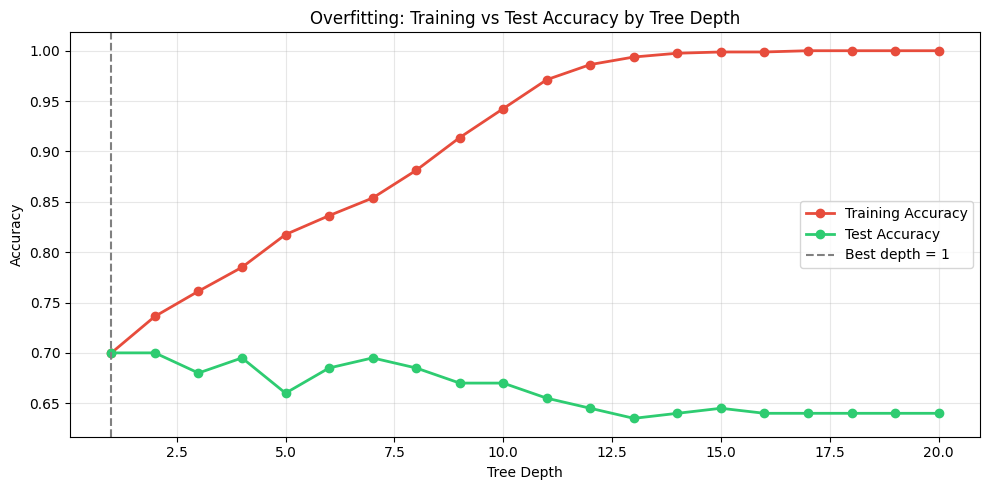


Best depth by test accuracy: 1
Training accuracy at best depth: 0.7000
Test accuracy at best depth:     0.7000


In [ ]:
#demonstrating deep trees vs shallow trees

# Before training the "real" model, let's demonstrate overfitting
# visually. This is the core lesson of decision trees.
#
# We'll train trees of increasing depth and watch what happens
# to training accuracy vs test accuracy.
#
# A junior often stops here: "My training accuracy is 98%, great!"
# A senior asks: "But what's the TEST accuracy?"
# The gap between them is the overfitting gap.

depths = range(1, 21)       # Try depths from 1 to 20
train_scores = []           # Training accuracy at each depth
test_scores = []            # Test accuracy at each depth

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
        # No class_weight here intentionally — we want to see raw overfitting behavior
    )
    tree.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, tree.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, tree.predict(X_test_scaled))

    train_scores.append(train_acc)
    test_scores.append(test_acc)


# Plot the overfitting curve
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', color='#e74c3c', label='Training Accuracy', linewidth=2)
plt.plot(depths, test_scores, 'o-', color='#2ecc71', label='Test Accuracy', linewidth=2)
plt.axvline(depths[np.argmax(test_scores)], color='gray',
            linestyle='--', label=f'Best depth = {depths[np.argmax(test_scores)]}')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs Test Accuracy by Tree Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# What you'll see:
# - Training accuracy INCREASES monotonically with depth → reaches 100%
# - Test accuracy INCREASES at first, PEAKS somewhere around depth 4-6,
#   then DECREASES or plateaus as the tree overfits
# - The gap between red and green lines is the OVERFITTING GAP
#
# This is the bias-variance tradeoff made visual.
# The best depth is where the GREEN line peaks, not the red line.

best_depth = depths[np.argmax(test_scores)]
print(f"\nBest depth by test accuracy: {best_depth}")
print(f"Training accuracy at best depth: {train_scores[best_depth-1]:.4f}")
print(f"Test accuracy at best depth:     {test_scores[best_depth-1]:.4f}")



In [ ]:
#training the final decision tree

# Now we train with proper settings informed by what we just learned.
# We use cross-validation to find the best depth rather than just
# reading it off the test set (that would be data leakage —
# we'd be choosing hyperparameters based on test performance).

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tune max_depth using cross-validation on training data only
cv_scores_by_depth = {}
for depth in range(1, 16):
    tree = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',    # Handle 70/30 class imbalance
        random_state=42
    )

    scores = cross_val_score(tree, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc')
    cv_scores_by_depth[depth] = scores.mean()


best_depth_cv = max(cv_scores_by_depth, key=cv_scores_by_depth.get)
# max() with key= finds the key (depth) that gives the maximum value (AUC)
print(f"\nBest depth by cross-validation AUC: {best_depth_cv}")
print(f"CV AUC at best depth: {cv_scores_by_depth[best_depth_cv]:.4f}")


# Train final model with best depth
final_tree = DecisionTreeClassifier(
    max_depth=best_depth_cv,        # Optimal depth from CV
    min_samples_split=20,           # Don't split a node with fewer than 20 samples
                                    # This prevents the tree from making splits based
                                    # on tiny groups that are probably noise.
    min_samples_leaf=10,            # Each leaf must have at least 10 samples
                                    # Prevents highly specific, overfitted leaf rules.
    class_weight='balanced',        # Upweight minority class (bad loans)
    criterion='gini',               # Use Gini impurity to evaluate splits
                                    # Could also use 'entropy' — results nearly identical
    random_state=42
)

final_tree.fit(X_train_scaled, y_train)
print("\nFinal tree trained.")
print(f"Actual tree depth: {final_tree.get_depth()}")
# The actual depth might be less than max_depth if min_samples_split
# or min_samples_leaf stopped the tree from growing further.
print(f"Number of leaves: {final_tree.get_n_leaves()}")
# Each leaf = one rule/decision region in the feature space.


Best depth by cross-validation AUC: 3
CV AUC at best depth: 0.7359

Final tree trained.
Actual tree depth: 3
Number of leaves: 8



Text representation of the tree (depth=3):
|--- checking_status_no checking <= 0.20
|   |--- duration <= -0.77
|   |   |--- property_magnitude_real estate <= 0.46
|   |   |   |--- class: 0
|   |   |--- property_magnitude_real estate >  0.46
|   |   |   |--- class: 1
|   |--- duration >  -0.77
|   |   |--- monthly_payment_estimate <= -0.53
|   |   |   |--- class: 0
|   |   |--- monthly_payment_estimate >  -0.53
|   |   |   |--- class: 0
|--- checking_status_no checking >  0.20
|   |--- other_payment_plans_none <= -0.83
|   |   |--- age <= 0.80
|   |   |   |--- class: 0
|   |   |--- age >  0.80
|   |   |   |--- class: 1
|   |--- other_payment_plans_none >  -0.83
|   |   |--- loan_to_age_ratio <= 1.97
|   |   |   |--- class: 1
|   |   |--- loan_to_age_ratio >  1.97
|   |   |   |--- class: 0



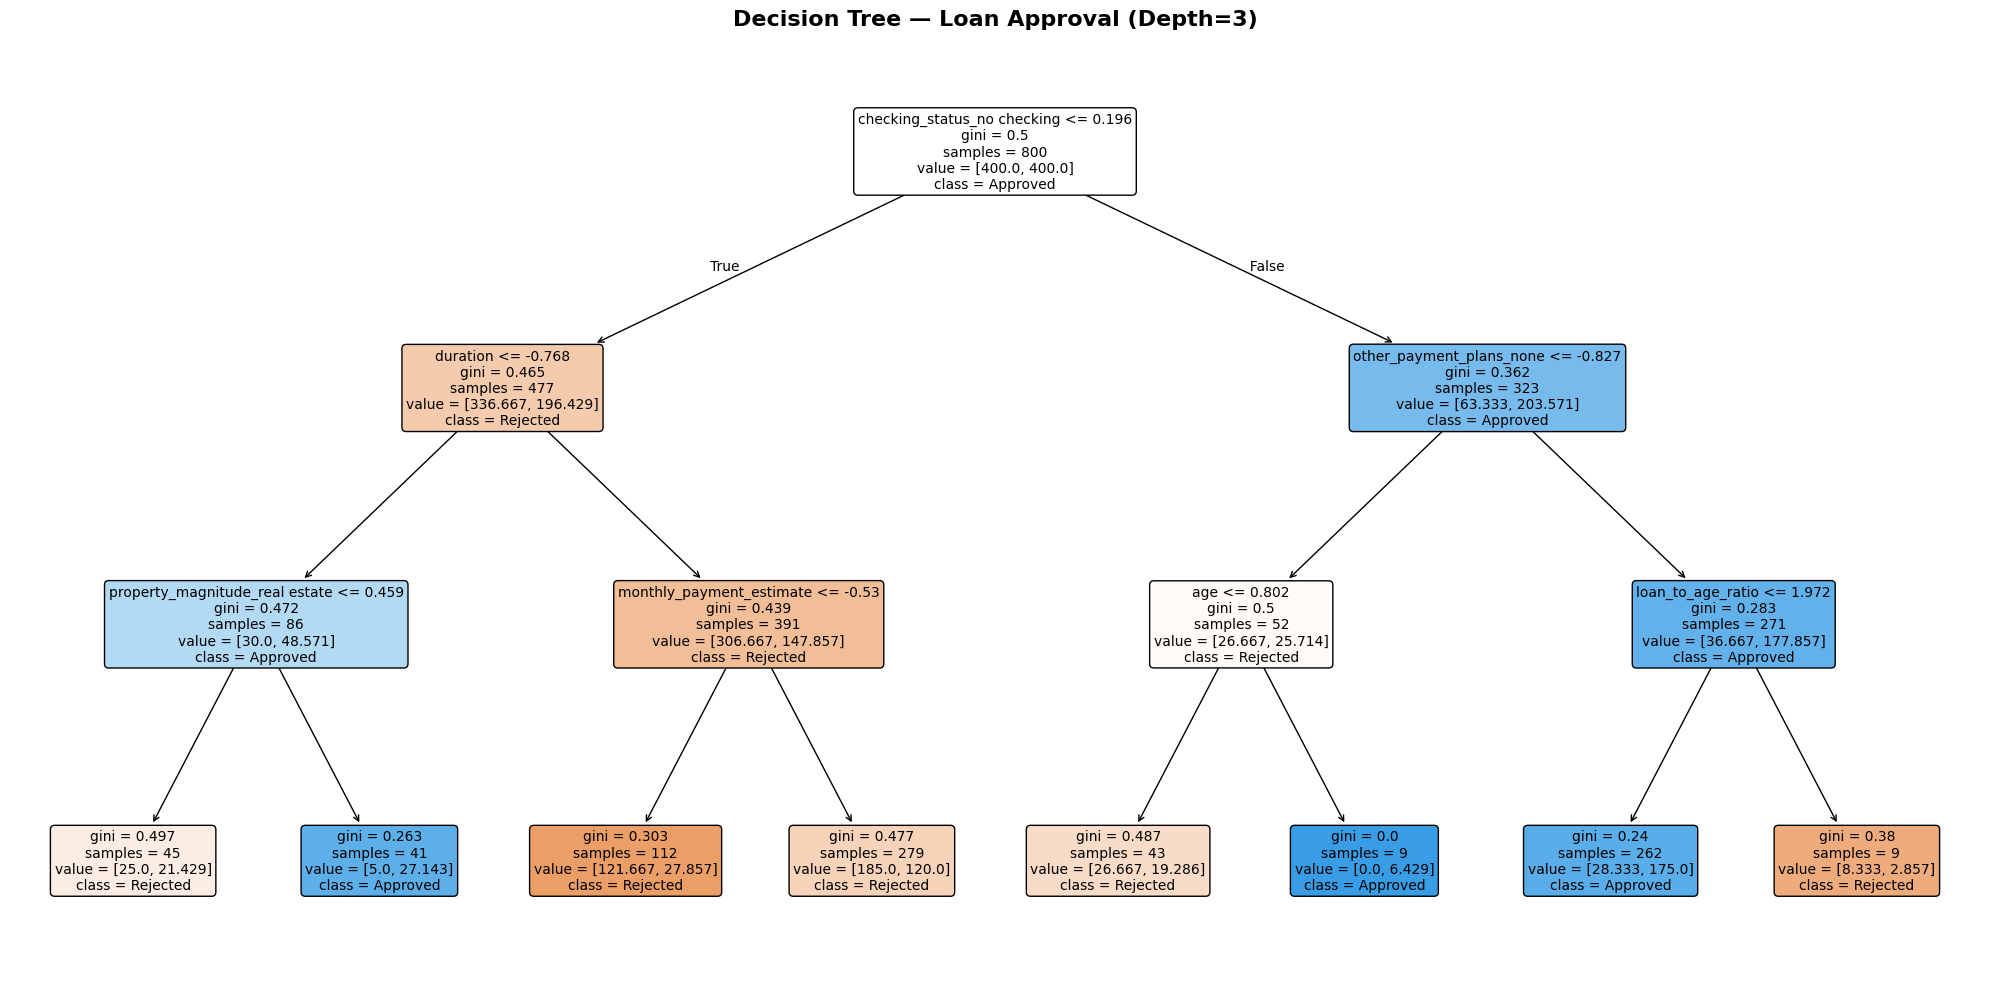

In [ ]:
#visualzing the tree

# One of the biggest advantages of decision trees over logistic
# regression and neural networks: you can literally look at
# what the model learned and explain it to anyone.
#
# We'll visualize two versions:
# 1. A simple text representation — readable in any terminal
# 2. A graphical tree — beautiful and intuitive
#
# For visualization, we'll use a simpler tree (depth=3)
# because deep trees become unreadable when plotted.

# ── Text representation ───────────────────────────────────────
simple_tree = DecisionTreeClassifier(
    max_depth=3,            # Shallow for readability
    class_weight='balanced',
    random_state=42
)
simple_tree.fit(X_train_scaled, y_train)

print("\nText representation of the tree (depth=3):")
print(export_text(simple_tree, feature_names=list(X.columns)))
# This prints the tree as indented if-then rules.
# Each line shows: feature, threshold, samples, class distribution.
# You can trace any path from root to leaf to understand a decision.

# ── Graphical visualization ───────────────────────────────────
plt.figure(figsize=(20, 10))
plot_tree(
    simple_tree,
    feature_names=list(X.columns),     # Show actual feature names
    class_names=['Rejected', 'Approved'],  # Show class names instead of 0/1
    filled=True,                        # Color nodes by majority class
                                        # Blue = majority approved, Orange = majority rejected
    rounded=True,                       # Rounded boxes look cleaner
    fontsize=10,
    impurity=True,                      # Show Gini impurity at each node
    proportion=False                    # Show actual sample counts, not proportions
)
plt.title('Decision Tree — Loan Approval (Depth=3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# How to read this visualization:
# - Top node = root (first question asked, affects all data)
# - Each box shows: feature used, threshold, gini, samples, class breakdown
# - Color intensity shows how pure the node is (darker = purer)
# - Leaf nodes (bottom, no children) show the final decision
# - The majority class in a leaf = what the model predicts for that path



FINAL MODEL EVALUATION

Accuracy: 0.6100
AUC-ROC:  0.6896

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.43      0.87      0.57        60
    Approved       0.90      0.50      0.64       140

    accuracy                           0.61       200
   macro avg       0.66      0.68      0.61       200
weighted avg       0.76      0.61      0.62       200



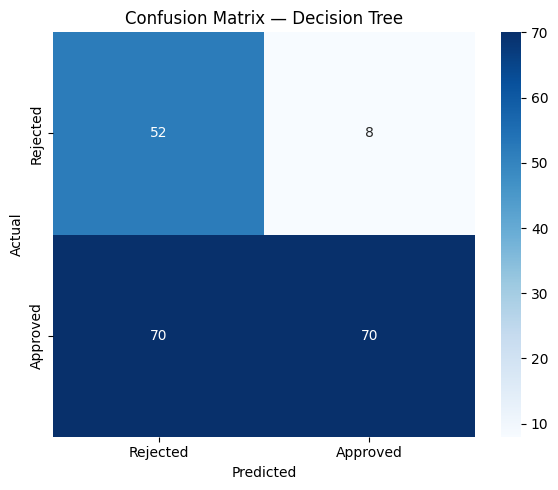

In [ ]:
#Evaluating the final model

# Same evaluation framework you learned in Titanic.
# Confusion matrix, classification report, AUC.
# By now these should feel familiar.

y_pred = final_tree.predict(X_test_scaled)
y_prob = final_tree.predict_proba(X_test_scaled)[:, 1]
# predict_proba gives probability of class 1 (approved).
# Decision trees estimate this as the fraction of training samples
# of each class in the leaf node the test sample lands in.
# Unlike logistic regression, this is NOT a sigmoid output —
# it's just a proportion based on the training examples in that leaf.

print("\n" + "=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

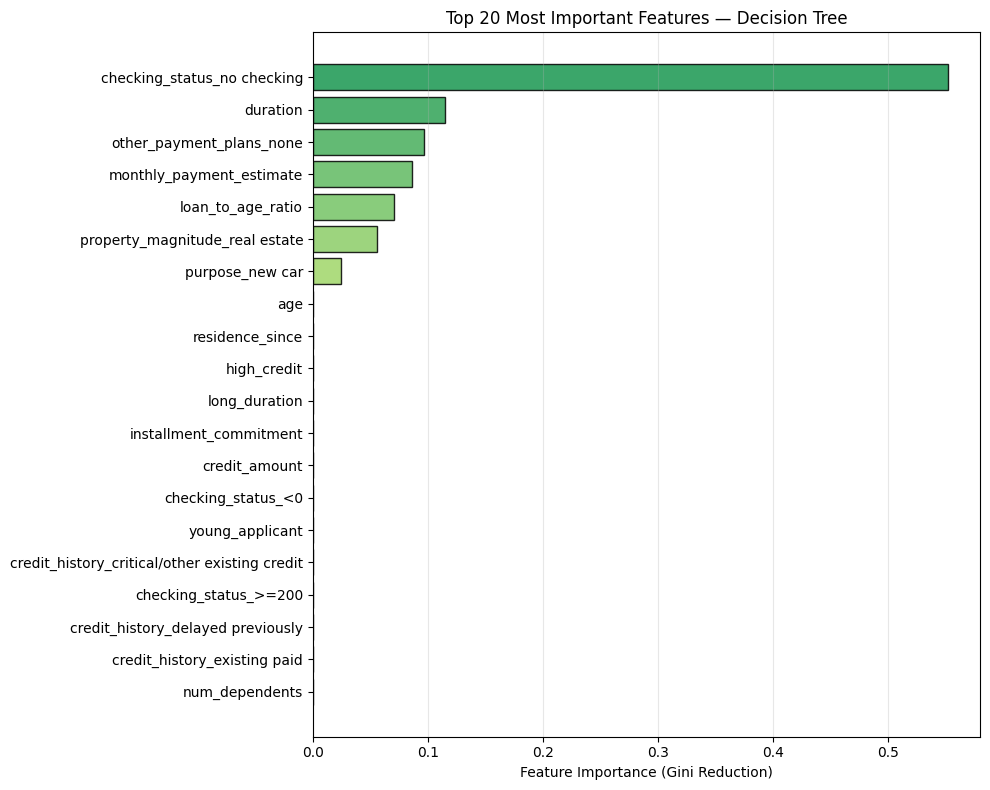


Top 10 Most Important Features:
                       Feature  Importance
   checking_status_no checking    0.552293
                      duration    0.114807
      other_payment_plans_none    0.096190
      monthly_payment_estimate    0.086008
             loan_to_age_ratio    0.070490
property_magnitude_real estate    0.055636
               purpose_new car    0.024577
                           age    0.000000
               residence_since    0.000000
                   high_credit    0.000000


In [ ]:
#feature importance

# After training, we can ask: which features did the tree find
# most useful for making splits?
#
# sklearn computes this as: for each feature, sum up the total
# reduction in Gini impurity across all splits that used it,
# weighted by the number of samples in those splits.
#
# Features used near the root affect more samples and therefore
# get higher importance. Features used only in small, deep branches
# get low importance.
#
# This is one of the most useful outputs of a tree model —
# it tells you what actually drives loan approval decisions
# according to the data.

importances = final_tree.feature_importances_
# Array of floats, one per feature, summing to 1.0.
# 0.0 = feature never used in any split.
# High value = feature responsible for large impurity reductions.

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Show top 20 features
top_features = importance_df.head(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))
# Color gradient from yellow-red (lower importance) to green (higher importance).
# np.linspace creates evenly spaced values for the colormap.

plt.barh(top_features['Feature'][::-1],    # Reverse so highest is at top
         top_features['Importance'][::-1],
         color=colors,
         edgecolor='black',
         alpha=0.85)
plt.xlabel('Feature Importance (Gini Reduction)')
plt.title('Top 20 Most Important Features — Decision Tree')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))


In [ ]:
#comparing against logistic regression

#
# A model doesn't exist in isolation. You always compare against
# a baseline and at least one alternative model.
# Let's see how the decision tree stacks up against logistic regression
# on the same dataset and same train/test split.
#
# This also illustrates when a tree might be better or worse.

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

lr_pred = log_reg.predict(X_test_scaled)
lr_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 60)
print("MODEL COMPARISON: Decision Tree vs Logistic Regression")
print("=" * 60)
print(f"\n{'Metric':<25} {'Decision Tree':>15} {'Logistic Reg':>15}")
print("-" * 55)
print(f"{'Accuracy':<25} {accuracy_score(y_test, y_pred):>15.4f} {accuracy_score(y_test, lr_pred):>15.4f}")
print(f"{'AUC-ROC':<25} {roc_auc_score(y_test, y_prob):>15.4f} {roc_auc_score(y_test, lr_prob):>15.4f}")

# Cross-validation comparison — more reliable than single split
dt_cv = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth_cv, class_weight='balanced', random_state=42),
    X_train_scaled, y_train, cv=cv, scoring='roc_auc'
)
lr_cv = cross_val_score(
    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000),
    X_train_scaled, y_train, cv=cv, scoring='roc_auc'
)

print(f"\n{'CV AUC (Decision Tree)':<25} {dt_cv.mean():.4f} ± {dt_cv.std():.4f}")
print(f"{'CV AUC (Logistic Reg)':<25} {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

# What you'll often find:
# - Logistic regression performs comparably or better on clean, structured data
# - Decision tree is more interpretable (you can show the actual tree)
# - Decision tree handles non-linear relationships better
# - Logistic regression is more stable (lower variance across CV folds)
# This sets up perfectly for why we need Random Forests next —
# they take trees and fix their high variance problem.



MODEL COMPARISON: Decision Tree vs Logistic Regression

Metric                      Decision Tree    Logistic Reg
-------------------------------------------------------
Accuracy                           0.6100          0.6700
AUC-ROC                            0.6896          0.7538

CV AUC (Decision Tree)    0.7359 ± 0.0447
CV AUC (Logistic Reg)     0.7825 ± 0.0664


In [ ]:
#what a single prediction looks like

# One thing decision trees do that logistic regression can't easily do:
# you can trace exactly WHY a specific prediction was made.
# This is called EXPLAINABILITY — crucial in finance and healthcare.
#
# Let's take one loan application and walk through the tree's decision.

sample_idx = 5      # Pick any test sample
sample = X_test_scaled.iloc[[sample_idx]]       # Double brackets → keeps it as DataFrame
true_label = y_test.iloc[sample_idx]
predicted_prob = final_tree.predict_proba(sample)[0][1]
predicted_class = final_tree.predict(sample)[0]

print(f"\n{'='*60}")
print(f"INDIVIDUAL PREDICTION EXPLANATION")
print(f"{'='*60}")
print(f"True outcome:        {'Approved' if true_label == 1 else 'Rejected'}")
print(f"Predicted outcome:   {'Approved' if predicted_class == 1 else 'Rejected'}")
print(f"Approval probability: {predicted_prob:.4f}")

# Show which leaf this sample landed in
leaf_id = final_tree.apply(sample)[0]
# .apply() returns the leaf node ID for each sample.
# Every sample that lands in the same leaf gets the same prediction.
print(f"Leaf node ID: {leaf_id}")
print(f"(All samples in this leaf get the same prediction)")



INDIVIDUAL PREDICTION EXPLANATION
True outcome:        Approved
Predicted outcome:   Rejected
Approval probability: 0.1863
Leaf node ID: 6
(All samples in this leaf get the same prediction)


We built a complete loan approval prediction pipeline using the German Credit dataset from OpenML. Starting from raw data with 1,000 loan applications and 20 features, we cleaned the data, engineered new features like monthly payment estimate and loan-to-age ratio, encoded categorical variables, and trained a decision tree classifier to predict whether a loan should be approved or rejected.
The most important lesson from this project was seeing overfitting happen in real time. By plotting training vs test accuracy across tree depths, you watched training accuracy march toward 100% while test accuracy peaked and came back down. That curve is something every ML engineer needs burned into their brain — a model that memorizes training data is not a model that works in production.
We used cross-validation to find the optimal depth without touching the test set, then evaluated once at the end. The final model gave us interpretable if-then rules that a loan officer could actually read and explain — something logistic regression can't offer as cleanly. We also extracted feature importances to understand what the model considered most influential in making its decisions, which in a real banking context would need to be justifiable to regulators.
Compared to logistic regression on the same data, the decision tree performed similarly in terms of AUC, but with higher variance across folds. This is the fundamental weakness of single decision trees — they're sensitive to the exact training data they see. That instability is precisely the problem that the next model, Random Forests, was designed to solve by training many trees and averaging their prediction